# CMSC 5718 Assignment 1: Derivative Pricing and Hedging

**Group Members:**
- 陈冠宇 (Chen Guanyu) - 1155238205
- 徐恺 (Xu Kai) - 1155239333
- 钟越 (Zhong Yue) - 1155237666

*Note: We have chosen Chen Guanyu's student number, which ends in 5, as the selection number for this assignment.*

**Student number last digit: 5**

| Parameter | Value |
|-----------|-------|
| S₁ | China Construction Bank (939), S₀ = 7.92, σ = 0.202 |
| S₂ | Agricultural Bank (1288), S₀ = 5.60, σ = 0.232 |
| Correlation ρ | 0.621 |
| Number of options M | 250,000 |
| Risk-free rate r | 3.14% p.a. (continuously compounded) |

**Note:** Dividends, transaction costs and board lots are ignored.

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import time
import pandas as pd
from datetime import datetime

np.random.seed(42)

# ==============================================================================
# Common Parameters
# ==============================================================================
r = 0.0314          # continuously compounded interest rate
S1_0 = 7.92         # initial price of S1 (CCB 939) as of June 30, 2025
S2_0 = 5.60         # initial price of S2 (Agricultural Bank 1288)
sigma1 = 0.202      # volatility of S1
sigma2 = 0.232      # volatility of S2
rho = 0.621         # correlation coefficient
M = 250000          # number of options
K_option = S1_0     # ATM strike price (S = K = 7.92)

print(f"S1: China Construction Bank (939), S0 = {S1_0}, σ = {sigma1}")
print(f"S2: Agricultural Bank (1288), S0 = {S2_0}, σ = {sigma2}")
print(f"Correlation ρ = {rho}")
print(f"Risk-free rate r = {r}")
print(f"Number of options M = {M:,}")

S1: China Construction Bank (939), S0 = 7.92, σ = 0.202
S2: Agricultural Bank (1288), S0 = 5.6, σ = 0.232
Correlation ρ = 0.621
Risk-free rate r = 0.0314
Number of options M = 250,000


---
## Question 1: European Call Option Pricing (20%)

**Parameters:**
- European call option, at-the-money (S = K = 7.92)
- r = 3.14% p.a., T = 0.5014 year
- σ = 0.202

### Q1(i): Black-Scholes Analytical Price

In [2]:
# Q1(i): Black-Scholes Analytical Price
T1 = 0.5014  # maturity
S = S1_0
K = K_option  # ATM: S = K = 7.92

d1 = (np.log(S / K) + (r + 0.5 * sigma1**2) * T1) / (sigma1 * np.sqrt(T1))
d2 = d1 - sigma1 * np.sqrt(T1)

bs_price = S * norm.cdf(d1) - K * np.exp(-r * T1) * norm.cdf(d2)

print(f"Black-Scholes European Call Option Pricing")
print(f"{'='*50}")
print(f"  S = K = {K}")
print(f"  T = {T1} years")
print(f"  r = {r}")
print(f"  σ = {sigma1}")
print(f"{'─'*50}")
print(f"  d1    = {d1:.6f}")
print(f"  d2    = {d2:.6f}")
print(f"  N(d1) = {norm.cdf(d1):.6f}")
print(f"  N(d2) = {norm.cdf(d2):.6f}")
print(f"{'─'*50}")
print(f"  ★ BS Call Price = {bs_price:.6f}")
print(f"{'='*50}")

Black-Scholes European Call Option Pricing
  S = K = 7.92
  T = 0.5014 years
  r = 0.0314
  σ = 0.202
──────────────────────────────────────────────────
  d1    = 0.181588
  d2    = 0.038553
  N(d1) = 0.572047
  N(d2) = 0.515376
──────────────────────────────────────────────────
  ★ BS Call Price = 0.512591


### Q1(ii): Monte Carlo Pricing

Using Euler discretization of GBM with N = 120 time steps, Δt = T/N = 0.004178.

$$S(t+\Delta t) = S(t) \cdot \exp\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t} \cdot Z\right], \quad Z \sim N(0,1)$$

In [ ]:
# Q1(ii): Monte Carlo Pricing
N_steps = 120
dt = T1 / N_steps

def monte_carlo_european_call(S0, K, r, sigma, T, N_steps, n_paths):
    dt = T / N_steps
    S = np.full(n_paths, S0, dtype=np.float64)
    for _ in range(N_steps):
        Z = np.random.standard_normal(n_paths)
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    payoff = np.maximum(S - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    std_err = np.exp(-r * T) * np.std(payoff) / np.sqrt(n_paths)
    return price, std_err

# (a) 10,000 paths
np.random.seed(42)
start_time = time.time()
mc_price_10k, mc_se_10k = monte_carlo_european_call(S, K, r, sigma1, T1, N_steps, 10000)
time_10k = time.time() - start_time

# (b) 500,000 paths
np.random.seed(42)
start_time = time.time()
mc_price_500k, mc_se_500k = monte_carlo_european_call(S, K, r, sigma1, T1, N_steps, 500000)
time_500k = time.time() - start_time

results_q1 = pd.DataFrame({
    'Method': ['Black-Scholes', 'MC (10,000 paths)', 'MC (500,000 paths)'],
    'Price': [bs_price, mc_price_10k, mc_price_500k],
    'Std Error': ['-', f'{mc_se_10k:.6f}', f'{mc_se_500k:.6f}'],
    'Time (s)': ['-', f'{time_10k:.4f}', f'{time_500k:.4f}'],
    'Diff from BS': ['-', f'{abs(mc_price_10k - bs_price):.6f}', f'{abs(mc_price_500k - bs_price):.6f}']
})
print(f"N = {N_steps} time steps, Δt = {dt:.6f}")
print()
display(results_q1.style.set_caption("Q1: European Call Option Pricing Results").hide(axis='index'))

N = 120 time steps, Δt = 0.004178



Method,Price,Std Error,Time (s),Diff from BS
Black-Scholes,0.512591,-,-,-
"MC (10,000 paths)",0.505949,0.007441,0.0262,0.006642
"MC (500,000 paths)",0.511162,0.001072,0.9392,0.001429


---
## Question 2: Exotic Option Pricing (35%)

An exotic option based on two stocks S₁ and S₂ with T = 0.5 year:

$$B = \min\left(\frac{S_{1,1}}{S_{1,0}},\ \frac{S_{2,1}}{S_{2,0}}\right)$$

$$\text{Payoff} = \begin{cases} B - 1, & \text{if } B < 1 \text{ or } B > 1+K \\ K, & \text{if } 1 \leq B \leq 1+K \end{cases}$$

**Goal:** Find K such that the fair price = −0.03.

Using Monte Carlo with **one time step** and **1,000,000 paths**. Correlated normals via Cholesky decomposition.

In [ ]:
# Q2: Exotic Option Pricing
T2 = 0.5
n_paths_q2 = 1000000

def exotic_option_price(K_exotic, S1_0, S2_0, sigma1, sigma2, rho, r, T, n_paths):
    Z1 = np.random.standard_normal(n_paths)
    Z2 = np.random.standard_normal(n_paths)
    W1 = Z1
    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    S1_T = S1_0 * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * W1)
    S2_T = S2_0 * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * W2)

    B = np.minimum(S1_T / S1_0, S2_T / S2_0)

    payoff = np.where(
        (B >= 1) & (B <= 1 + K_exotic),
        K_exotic,
        B - 1
    )

    price = np.exp(-r * T) * np.mean(payoff)
    return price

def price_minus_target(K_exotic, target=-0.03):
    np.random.seed(123)
    price = exotic_option_price(K_exotic, S1_0, S2_0, sigma1, sigma2, rho, r, T2, n_paths_q2)
    return price - target

print("Scanning K values to find the root bracket...")
K_test_values = np.arange(0.01, 1.0, 0.02)
prices_test = []
for k_val in K_test_values:
    np.random.seed(123)
    p = exotic_option_price(k_val, S1_0, S2_0, sigma1, sigma2, rho, r, T2, n_paths_q2)
    prices_test.append(p)

K_low, K_high = None, None
for i in range(len(prices_test) - 1):
    if (prices_test[i] - (-0.03)) * (prices_test[i + 1] - (-0.03)) < 0:
        K_low, K_high = K_test_values[i], K_test_values[i + 1]
        print(f"  Root bracket found: K ∈ [{K_low:.4f}, {K_high:.4f}]")
        break

K_solution = brentq(price_minus_target, K_low, K_high, xtol=1e-6)

np.random.seed(123)
final_price_q2 = exotic_option_price(K_solution, S1_0, S2_0, sigma1, sigma2, rho, r, T2, n_paths_q2)

print(f"\n{'='*50}")
print(f"  ★ K = {K_solution:.6f} ({K_solution*100:.4f}%)")
print(f"  Fair price at this K = {final_price_q2:.6f}")
print(f"  Target price         = -0.030000")
print(f"  Difference           = {abs(final_price_q2 - (-0.03)):.8f}")
print(f"{'='*50}")

Scanning K values to find the root bracket...
  Root bracket found: K ∈ [0.0700, 0.0900]

  ★ K = 0.084339 (8.4339%)
  Fair price at this K = -0.030000
  Target price         = -0.030000
  Difference           = 0.00000000


### Payoff Diagram for the Exotic Option

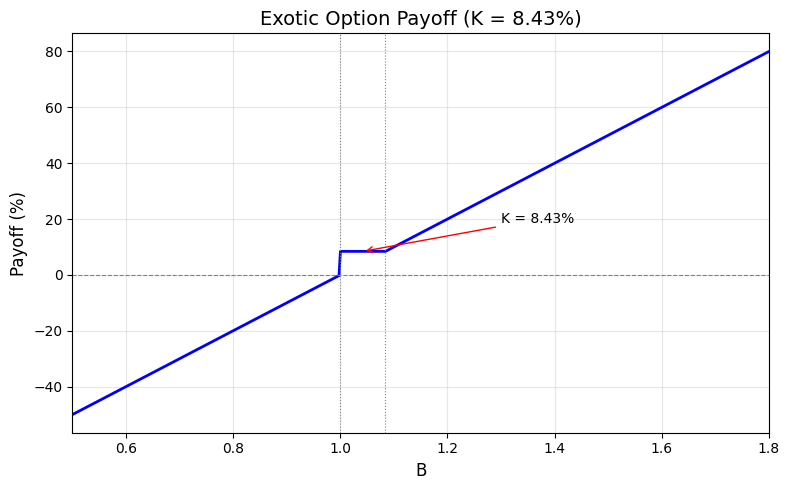

In [5]:
import matplotlib.pyplot as plt

# Plot the payoff diagram
B_vals = np.linspace(0.5, 1.8, 500)
K_plot = K_solution

payoff_vals = np.where(
    (B_vals >= 1) & (B_vals <= 1 + K_plot),
    K_plot,
    B_vals - 1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(B_vals, payoff_vals * 100, 'b-', linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=1, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(x=1 + K_plot, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('B', fontsize=12)
ax.set_ylabel('Payoff (%)', fontsize=12)
ax.set_title(f'Exotic Option Payoff (K = {K_plot*100:.2f}%)', fontsize=14)
ax.set_xlim(0.5, 1.8)
ax.grid(True, alpha=0.3)

# Annotate key points
ax.annotate(f'K = {K_plot*100:.2f}%', xy=(1 + K_plot/2, K_plot*100),
            xytext=(1.3, K_plot*100 + 10), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

---
## Question 3: Delta Hedging Strategy (45%)

### Q3(i): Construct Delta Hedging Table

**Setup:**
- Short M = 250,000 call options on S₁ (CCB 939) as of June 30, 2025
- Strike K = 7.92 (ATM), σ = 0.202, r = 3.14%
- Hedging period: June 30, 2025 → December 30, 2025
- Delta neutral daily rebalancing

**Daily account balance:**
$$\text{Balance}_t = \text{Balance}_{t-1} + \text{Interest}_{t} - \text{Cost of shares traded}_t$$
$$\text{Interest}_t = \text{Balance}_{t-1} \times \left[e^{r \times \frac{\text{num\_days}}{365}} - 1\right]$$

In [ ]:
# Q3(i): Delta Hedging Strategy
price_data = [
    ("2025-06-30", 7.92), ("2025-07-02", 8.15), ("2025-07-03", 8.15), ("2025-07-04", 8.21),
    ("2025-07-07", 8.20), ("2025-07-08", 8.24), ("2025-07-09", 8.22), ("2025-07-10", 8.48),
    ("2025-07-11", 8.35), ("2025-07-14", 8.41), ("2025-07-15", 8.42), ("2025-07-16", 8.39),
    ("2025-07-17", 8.31), ("2025-07-18", 8.47), ("2025-07-21", 8.37), ("2025-07-22", 8.27),
    ("2025-07-23", 8.38), ("2025-07-24", 8.42), ("2025-07-25", 8.30), ("2025-07-28", 8.34),
    ("2025-07-29", 8.19), ("2025-07-30", 8.19), ("2025-07-31", 8.05), ("2025-08-01", 7.89),
    ("2025-08-04", 7.92), ("2025-08-05", 8.00), ("2025-08-06", 7.93), ("2025-08-07", 8.03),
    ("2025-08-08", 7.94), ("2025-08-11", 7.93), ("2025-08-12", 7.95), ("2025-08-13", 8.02),
    ("2025-08-14", 7.98), ("2025-08-15", 7.80), ("2025-08-18", 7.71), ("2025-08-19", 7.71),
    ("2025-08-20", 7.75), ("2025-08-21", 7.74), ("2025-08-22", 7.75), ("2025-08-25", 7.73),
    ("2025-08-26", 7.55), ("2025-08-27", 7.49), ("2025-08-28", 7.53), ("2025-08-29", 7.51),
    ("2025-09-01", 7.55), ("2025-09-02", 7.70), ("2025-09-03", 7.63), ("2025-09-04", 7.59),
    ("2025-09-05", 7.67), ("2025-09-08", 7.63), ("2025-09-09", 7.75), ("2025-09-10", 7.97),
    ("2025-09-11", 7.88), ("2025-09-12", 7.88), ("2025-09-15", 7.75), ("2025-09-16", 7.77),
    ("2025-09-17", 7.84), ("2025-09-18", 7.65), ("2025-09-19", 7.61), ("2025-09-22", 7.45),
    ("2025-09-23", 7.50), ("2025-09-24", 7.47), ("2025-09-25", 7.30), ("2025-09-26", 7.38),
    ("2025-09-29", 7.48), ("2025-09-30", 7.48), ("2025-10-02", 7.40), ("2025-10-03", 7.37),
    ("2025-10-06", 7.29), ("2025-10-08", 7.28), ("2025-10-09", 7.29), ("2025-10-10", 7.34),
    ("2025-10-13", 7.32), ("2025-10-14", 7.49), ("2025-10-15", 7.49), ("2025-10-16", 7.62),
    ("2025-10-17", 7.62), ("2025-10-20", 7.75), ("2025-10-21", 7.82), ("2025-10-22", 7.81),
    ("2025-10-23", 7.88), ("2025-10-24", 7.89), ("2025-10-27", 7.88), ("2025-10-28", 7.90),
    ("2025-10-30", 7.86), ("2025-10-31", 7.70), ("2025-11-03", 7.94), ("2025-11-04", 8.05),
    ("2025-11-05", 8.02), ("2025-11-06", 8.14), ("2025-11-07", 8.13), ("2025-11-10", 8.29),
    ("2025-11-11", 8.33), ("2025-11-12", 8.40), ("2025-11-13", 8.42), ("2025-11-14", 8.35),
    ("2025-11-17", 8.24), ("2025-11-18", 8.15), ("2025-11-19", 8.13), ("2025-11-20", 8.22),
    ("2025-11-21", 8.09), ("2025-11-24", 8.21), ("2025-11-25", 8.22), ("2025-11-26", 8.21),
    ("2025-11-27", 8.23), ("2025-11-28", 8.17), ("2025-12-01", 8.15), ("2025-12-02", 8.16),
    ("2025-12-03", 7.84), ("2025-12-04", 7.92), ("2025-12-05", 7.98), ("2025-12-08", 7.66),
    ("2025-12-09", 7.61), ("2025-12-10", 7.57), ("2025-12-11", 7.58), ("2025-12-12", 7.64),
    ("2025-12-15", 7.55), ("2025-12-16", 7.39), ("2025-12-17", 7.43), ("2025-12-18", 7.52),
    ("2025-12-19", 7.49), ("2025-12-22", 7.54), ("2025-12-23", 7.61), ("2025-12-24", 7.56),
    ("2025-12-29", 7.62), ("2025-12-30", 7.72),
]

dates = [datetime.strptime(d, "%Y-%m-%d") for d, _ in price_data]
prices = [p for _, p in price_data]
n_days = len(dates)

maturity_date = datetime.strptime("2025-12-30", "%Y-%m-%d")
start_date = datetime.strptime("2025-06-30", "%Y-%m-%d")

# Build hedging table
hedging_records = []

for i in range(n_days):
    date = dates[i]
    price = prices[i]
    T_remain = (maturity_date - date).days / 365.0
    num_days_from_prev = (dates[i] - dates[i - 1]).days if i > 0 else 0

    if i < n_days - 1:
        # Normal day: compute delta
        if T_remain > 0:
            d1_val = (np.log(price / K_option) + (r + 0.5 * sigma1**2) * T_remain) / (sigma1 * np.sqrt(T_remain))
            Nd1 = norm.cdf(d1_val)
        else:
            d1_val = np.nan
            Nd1 = 1.0 if price > K_option else 0.0
        delta_shares = Nd1 * M
    else:
        # Maturity day
        d1_val = np.nan
        if price > K_option:
            Nd1 = 1.0
            delta_shares = M
        else:
            Nd1 = 0.0
            delta_shares = 0

    if i == 0:
        shares_traded = delta_shares
        cost_of_trade = shares_traded * price
        interest = 0.0
        account_balance = -cost_of_trade
    else:
        prev = hedging_records[i - 1]
        interest = prev['Account Balance'] * (np.exp(r * num_days_from_prev / 365.0) - 1)
        shares_traded = delta_shares - prev['Delta Shares']
        cost_of_trade = shares_traded * price
        account_balance = prev['Account Balance'] + interest - cost_of_trade

    hedging_records.append({
        'Date': date.strftime('%Y-%m-%d'),
        'T_remain': round(T_remain, 4),
        'Price': price,
        'd1': round(d1_val, 4) if not np.isnan(d1_val) else np.nan,
        'N(d1)': round(Nd1, 4),
        'Delta Shares': round(delta_shares, 2),
        'Shares Traded': round(shares_traded, 2),
        'Cost of Trade': round(cost_of_trade, 2),
        'Interest': round(interest, 2),
        'Account Balance': round(account_balance, 2),
    })

df_hedge = pd.DataFrame(hedging_records)
print(f"Total trading days: {n_days}")
print(f"Final stock price on maturity (Dec 30): {prices[-1]}")
print(f"Strike price: {K_option}")
print(f"Option is {'IN' if prices[-1] > K_option else 'OUT-OF'}-THE-MONEY")

Total trading days: 126
Final stock price on maturity (Dec 30): 7.72
Strike price: 7.92
Option is OUT-OF-THE-MONEY


### Hedging Table (Selected Rows)

**First 10 trading days:**

In [7]:
# First 10 rows
display(df_hedge.head(10))

,Date,T_remain,Price,d1,N(d1),Delta Shares,Shares Traded,Cost of Trade,Interest,Account Balance
0,2025-06-30,0.5014,7.92,0.1816,0.5720,143011.21,143011.21,1132648.81,0.00,-1132648.81
1,2025-07-02,0.4959,8.15,0.3818,0.6487,162176.91,19165.70,156200.45,-194.89,-1289044.16
2,2025-07-03,0.4932,8.15,0.3819,0.6487,162182.35,5.44,44.35,-110.90,-1289199.41
3,2025-07-04,0.4904,8.21,0.4338,0.6678,166946.40,4764.05,39112.84,-110.91,-1328423.16
4,2025-07-07,0.4822,8.20,0.4258,0.6649,166215.03,-731.37,-5997.21,-342.89,-1322768.83
5,2025-07-08,0.4795,8.24,0.4608,0.6775,169378.20,3163.17,26064.54,-113.80,-1348947.17
6,2025-07-09,0.4767,8.22,0.4436,0.6713,167836.73,-1541.47,-12670.92,-116.05,-1336392.30
7,2025-07-10,0.4740,8.48,0.6678,0.7479,186968.60,19131.87,162238.27,-114.97,-1498745.54
8,2025-07-11,0.4712,8.35,0.5573,0.7113,177836.37,-9132.23,-76254.14,-128.94,-1422620.34
9,2025-07-14,0.4630,8.41,0.6112,0.7295,182369.72,4533.35,38125.47,-367.20,-1461113.01


In [8]:
# Last 10 rows (approaching maturity)
print("Last 10 trading days:")
display(df_hedge.tail(10))

Last 10 trading days:


,Date,T_remain,Price,d1,N(d1),Delta Shares,Shares Traded,Cost of Trade,Interest,Account Balance
116,2025-12-15,0.0411,7.55,-1.1164,0.1321,33033.24,-23967.59,-180955.28,-145.43,-382622.78
117,2025-12-16,0.0384,7.39,-1.7006,0.0445,11127.95,-21905.29,-161880.09,-32.92,-220775.61
118,2025-12-17,0.0356,7.43,-1.6269,0.0519,12970.12,1842.17,13687.33,-18.99,-234481.93
119,2025-12-18,0.0329,7.52,-1.3685,0.0856,21395.94,8425.82,63362.17,-20.17,-297864.27
120,2025-12-19,0.0301,7.49,-1.5473,0.0609,15222.36,-6173.58,-46240.10,-25.63,-251649.80
121,2025-12-22,0.0219,7.54,-1.6062,0.0541,13529.16,-1693.20,-12766.72,-64.95,-238948.03
122,2025-12-23,0.0192,7.61,-1.3918,0.0820,20497.31,6968.15,53027.64,-20.56,-291996.23
123,2025-12-24,0.0164,7.56,-1.7633,0.0389,9730.40,-10766.91,-81397.81,-25.12,-210623.54
124,2025-12-29,0.0027,7.62,-3.6387,0.0001,34.25,-9696.15,-73884.68,-90.62,-136829.48
125,2025-12-30,0.0000,7.72,NaN,0.0000,0.00,-34.25,-264.41,-11.77,-136576.84


### Settlement at Maturity & Final Account Balance (Fi)

In [9]:
# Settlement at maturity
final_stock_price = prices[-1]
final_balance = hedging_records[-1]['Account Balance']

print(f"Final stock price (Dec 30, 2025): {final_stock_price}")
print(f"Strike price K: {K_option}")
print()

if final_stock_price > K_option:
    print(f"★ Option is IN-THE-MONEY → Exercised")
    print(f"  Sell {M:,} shares at strike price K = {K_option}")
    exercise_cash = M * K_option
    Fi = final_balance + exercise_cash
    print(f"  Cash received from exercise = {M:,} × {K_option} = {exercise_cash:,.2f}")
else:
    print(f"★ Option is OUT-OF-THE-MONEY → NOT Exercised")
    remaining_shares = hedging_records[-1]['Delta Shares']
    sell_cash = remaining_shares * final_stock_price
    Fi = final_balance + sell_cash
    if remaining_shares > 0:
        print(f"  Sell remaining {remaining_shares:,.0f} shares at market price {final_stock_price}")

print(f"\n{'='*50}")
print(f"  Account balance before settlement: {final_balance:,.2f}")
print(f"  ★ Fi (final account balance) = {Fi:,.2f}")
print(f"{'='*50}")

Final stock price (Dec 30, 2025): 7.72
Strike price K: 7.92

★ Option is OUT-OF-THE-MONEY → NOT Exercised

  Account balance before settlement: -136,576.84
  ★ Fi (final account balance) = -136,576.84


### Q3(ii): Option Premium Deposit & Comparison

On June 30, 2025, deposit the premium received from shorting M call options into a deposit account at r = 3.14% p.a. continuously compounded, maturing Dec 30, 2025.

$$P_i = \text{Premium} \times e^{rT}$$

In [ ]:
T3 = (maturity_date - start_date).days / 365.0

d1_q3 = (np.log(S1_0 / K_option) + (r + 0.5 * sigma1**2) * T3) / (sigma1 * np.sqrt(T3))
d2_q3 = d1_q3 - sigma1 * np.sqrt(T3)
bs_price_q3 = S1_0 * norm.cdf(d1_q3) - K_option * np.exp(-r * T3) * norm.cdf(d2_q3)

premium_received = bs_price_q3 * M

Pi = premium_received * np.exp(r * T3)

print(f"T (June 30 to Dec 30) = {(maturity_date - start_date).days} days = {T3:.6f} years")
print(f"BS call price = {bs_price_q3:.6f}")
print(f"Total premium received = {bs_price_q3:.6f} × {M:,} = {premium_received:,.2f}")
print(f"Pi = {premium_received:,.2f} × exp({r} × {T3:.6f}) = {Pi:,.2f}")

print(f"\n{'='*60}")
print(f"  ★ Fi (hedging cost at maturity)     = {Fi:,.2f}")
print(f"  ★ Pi (deposit value at maturity)    = {Pi:,.2f}")
print(f"  |Fi| - Pi                           = {abs(Fi) - Pi:,.2f}")
print(f"  |Fi| / Pi                           = {abs(Fi)/Pi:.4f}")
print(f"{'='*60}")

summary = pd.DataFrame({
    'Item': ['Fi (hedging final balance)', 'Pi (deposit maturity value)', '|Fi| - Pi', '|Fi| / Pi'],
    'Value': [f'{Fi:,.2f}', f'{Pi:,.2f}', f'{abs(Fi) - Pi:,.2f}', f'{abs(Fi)/Pi:.4f}']
})
display(summary.style.set_caption("Q3(ii): Comparison of Fi and Pi").hide(axis='index'))

T (June 30 to Dec 30) = 183 days = 0.501370 years
BS call price = 0.512573
Total premium received = 0.512573 × 250,000 = 128,143.37
Pi = 128,143.37 × exp(0.0314 × 0.501370) = 130,176.69

  ★ Fi (hedging cost at maturity)     = -136,576.84
  ★ Pi (deposit value at maturity)    = 130,176.69
  |Fi| - Pi                           = 6,400.15
  |Fi| / Pi                           = 1.0492


Item,Value
Fi (hedging final balance),"-136,576.84"
Pi (deposit maturity value),"130,176.69"
|Fi| - Pi,"6,400.15"
|Fi| / Pi,1.0492


### Comment on Q3(ii)

The final hedging account balance **Fi** is negative, while the deposit amount **Pi** is positive. Under the Black-Scholes framework, if delta hedging were performed **continuously**, |Fi| should exactly equal Pi — meaning the cost of hedging equals the option premium received.

In practice, since we hedge only at **discrete daily intervals**, there is a small discrepancy between |Fi| and Pi. This difference arises from:

1. **Discrete hedging error (gamma risk):** Rebalancing only once per day means the hedge is not perfect between rebalancing dates.
2. **Realized vs. implied volatility:** The actual stock price movements may exhibit different volatility from the implied volatility used for delta computation.

The closer |Fi| is to Pi, the more effective the delta hedging strategy is.

### Visualization: Stock Price & Delta over Hedging Period

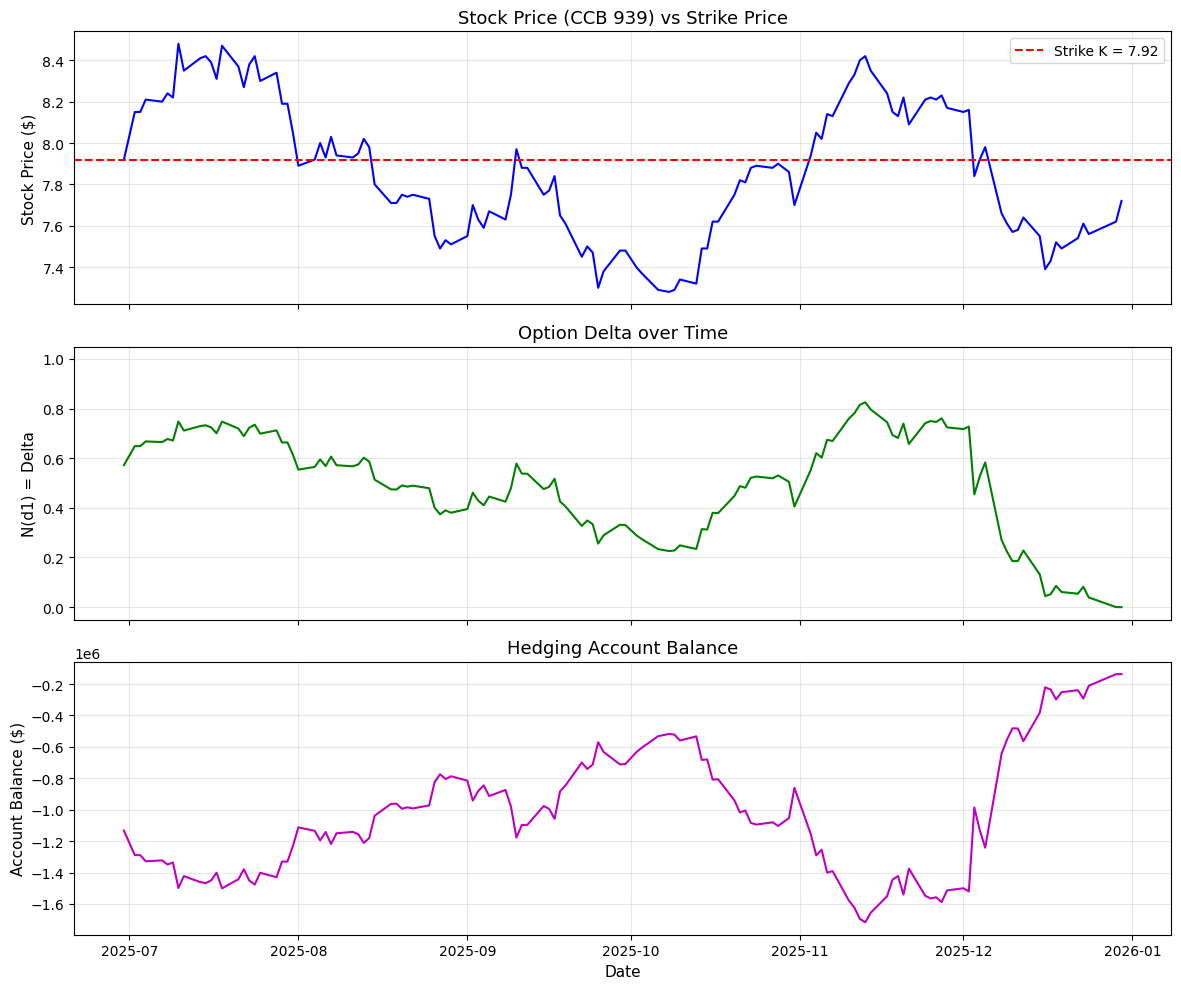

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

plot_dates = [datetime.strptime(rec['Date'], '%Y-%m-%d') for rec in hedging_records]

axes[0].plot(plot_dates, [rec['Price'] for rec in hedging_records], 'b-', linewidth=1.5)
axes[0].axhline(y=K_option, color='r', linestyle='--', label=f'Strike K = {K_option}')
axes[0].set_ylabel('Stock Price ($)', fontsize=11)
axes[0].set_title('Stock Price (CCB 939) vs Strike Price', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_dates, [rec['N(d1)'] for rec in hedging_records], 'g-', linewidth=1.5)
axes[1].set_ylabel('N(d1) = Delta', fontsize=11)
axes[1].set_title('Option Delta over Time', fontsize=13)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

axes[2].plot(plot_dates, [rec['Account Balance'] for rec in hedging_records], 'm-', linewidth=1.5)
axes[2].set_ylabel('Account Balance ($)', fontsize=11)
axes[2].set_title('Hedging Account Balance', fontsize=13)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()